In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

2.6.0+cu124


In [ ]:
!pip install -q torch_geometric
!pip install -q class_resolver
!pip3 install pymatting


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 2.1 MB/s eta 0:00:00


In [1]:
import torch.optim as optim
from tqdm import tqdm
import numpy as np
import torch
# import util
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from numpy import asarray
import tifffile as tiff
import torch.nn as nn
import torch.nn.functional as nnFn
import torch_geometric.nn as pyg_nn
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss
from torch.nn import CrossEntropyLoss
import random
from sklearn.cluster import KMeans

/home/snu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
fa_feature_path = "/home/snu/Downloads/Histogram_CN_FA_20bin_updated.npy"
Histogram_feature_CN_FA_array = np.load(fa_feature_path, allow_pickle=True)

# Load MCI features
fa_feature_path = "/home/snu/Downloads/Histogram_MCI_FA_20bin_updated.npy"
Histogram_feature_MCI_FA_array = np.load(fa_feature_path, allow_pickle=True)

# Combine features and labels
X = np.vstack([Histogram_feature_CN_FA_array, Histogram_feature_MCI_FA_array])
y = np.hstack([
    np.zeros(Histogram_feature_CN_FA_array.shape[0], dtype=np.int64),
    np.ones(Histogram_feature_MCI_FA_array.shape[0], dtype=np.int64)
])
np.random.seed(42)
perm = np.random.permutation(X.shape[0])
X = X[perm]
y = y[perm]
num_nodes, num_feats = X.shape
print(f"Features: {X.shape}, Labels: {y.shape}")

Features: (300, 180), Labels: (300,)


In [3]:
# F = np.concatenate((Histogram_feature_CN_FA_array, Histogram_feature_MCI_FA_array), axis=0)
# F = F.astype(np.float32)
# print("Combined Shape:", F.shape)
F = X
F = F.astype(np.float32)
print("Final Shape:", F.shape)
print("Data Type:", F.dtype)

Final Shape: (300, 180)
Data Type: float32


In [ ]:
kmeans = KMeans(n_clusters=2, random_state=11, max_iter=5000)
kmeans.fit(F)

# Cluster probabilities
klabels_trans = kmeans.transform(F)
klabels_trans = klabels_trans / klabels_trans.sum(axis=1, keepdims=True)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
kS = torch.tensor(klabels_trans, dtype=torch.float32).to(device)

In [ ]:
ground_truth_tensor = torch.tensor(y, dtype=torch.long).to(device)

In [ ]:
criterion = CrossEntropyLoss()
loss = criterion(kS, ground_truth_tensor)
y_pred = torch.argmax(kS, dim=1).cpu().numpy()

In [ ]:
acc_score = accuracy_score(y, y_pred)
acc_score_inverted = accuracy_score(y, 1 - y_pred)

if acc_score_inverted > acc_score:
    acc_score = acc_score_inverted
    y_pred = 1 - y_pred
    klabels_trans[:, [0, 1]] = klabels_trans[:, [1, 0]]

y_pred_proba = klabels_trans[:, 1]

prec_score = precision_score(y, y_pred)
rec_score = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
log_loss_value = log_loss(y, y_pred_proba)

# Print metrics
print("Accuracy Score:", acc_score)
print("Precision Score:", prec_score)
print("Recall Score:", rec_score)
print("F1 Score:", f1)
print("Log Loss:", log_loss_value)

Accuracy Score: 0.7233333333333334
Precision Score: 0.795774647887324
Recall Score: 0.6766467065868264
F1 Score: 0.7313915857605178
Log Loss: 0.6329267940589133


In [ ]:
print(y_pred_proba)

[0.58070135 0.5173665  0.6024661  0.42833897 0.63992417 0.41319692
 0.40443432 0.52194107 0.62788457 0.6054637  0.6190496  0.5484194
 0.5696041  0.51558375 0.6176691  0.61278    0.36077842 0.45798612
 0.60511065 0.62265915 0.4472961  0.6165393  0.59988374 0.5100882
 0.50809735 0.57097733 0.62535167 0.45453838 0.5961357  0.5679516
 0.47396523 0.60529846 0.48749137 0.4339891  0.5400738  0.6046543
 0.6050268  0.3965132  0.33363727 0.40369263 0.516602   0.48889285
 0.6390586  0.3995673  0.47126612 0.51765394 0.3468624  0.5515442
 0.44362676 0.4422733  0.5916453  0.603559   0.5070608  0.45696086
 0.6368534  0.3708288  0.38638628 0.43463573 0.3670015  0.41697344
 0.57749844 0.4155923  0.5132486  0.6026821  0.4205868  0.4231056
 0.37118647 0.5456966  0.40861076 0.4927506  0.3969468  0.47550297
 0.5097013  0.531328   0.5858435  0.37620237 0.44805217 0.4146688
 0.43271658 0.3806578  0.5359352  0.55302936 0.38918385 0.43754238
 0.4173982  0.37651342 0.39402163 0.4010827  0.44637883 0.37781817
 0

In [ ]:
import numpy as np
import torch
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss
from torch.nn import CrossEntropyLoss

fa_feature_path = "/home/snu/Downloads/Histogram_CN_FA_20bin_updated.npy"
Histogram_feature_CN_FA_array = np.load(fa_feature_path, allow_pickle=True)

# Load MCI features
fa_feature_path = "/home/snu/Downloads/Histogram_MCI_FA_20bin_updated.npy"
Histogram_feature_MCI_FA_array = np.load(fa_feature_path, allow_pickle=True)

# Combine features and labels
X = np.vstack([Histogram_feature_CN_FA_array, Histogram_feature_MCI_FA_array])
y = np.hstack([
    np.zeros(Histogram_feature_CN_FA_array.shape[0], dtype=np.int64),
    np.ones(Histogram_feature_MCI_FA_array.shape[0], dtype=np.int64)
])
np.random.seed(42)
perm = np.random.permutation(X.shape[0])
X = X[perm]
y = y[perm]
num_nodes, num_feats = X.shape
print(f"Features: {X.shape}, Labels: {y.shape}")

F = X.astype(np.float32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = CrossEntropyLoss()

num_runs = 10

acc_scores = []
prec_scores = []
rec_scores = []
f1_scores = []
log_losses = []
ce_losses = [] # Initialize the list here

for run in range(num_runs):
    print(f"\n--- Run {run+1}/{num_runs} ---")
    np.random.seed(run)
    torch.manual_seed(run)

    kmeans = KMeans(n_clusters=2, random_state=run, max_iter=5000)
    kmeans.fit(F)

    klabels_trans = kmeans.transform(F)
    klabels_trans = klabels_trans / klabels_trans.sum(axis=1, keepdims=True)

    kS = torch.tensor(klabels_trans, dtype=torch.float32).to(device)
    ground_truth_tensor = torch.tensor(y, dtype=torch.long).to(device)


    ce_loss_value = criterion(kS, ground_truth_tensor).item()


    y_pred = torch.argmax(kS, dim=1).cpu().numpy()
    acc_score = accuracy_score(y, y_pred)

    acc_score_inverted = accuracy_score(y, 1 - y_pred)
    if acc_score_inverted > acc_score:
        acc_score = acc_score_inverted
        y_pred = 1 - y_pred
        klabels_trans[:, [0, 1]] = klabels_trans[:, [1, 0]]

    y_pred_proba = klabels_trans[:, 1]

    prec_score = precision_score(y, y_pred)
    rec_score = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    log_loss_value = log_loss(y, y_pred_proba)

    acc_scores.append(acc_score)
    prec_scores.append(prec_score)
    rec_scores.append(rec_score)
    f1_scores.append(f1)
    log_losses.append(log_loss_value)
    ce_losses.append(ce_loss_value)

    print(f"Run {run+1} | Acc: {acc_score:.4f} | Prec: {prec_score:.4f} | Rec: {rec_score:.4f} | "
          f"F1: {f1:.4f} | LogLoss: {log_loss_value:.4f} | CE Loss: {ce_loss_value:.4f}")

print("\n================ FINAL SUMMARY ================\n")
print(f"{'Metric':>15} | {'Mean':>10} ± {'Std':<10}")
print("-" * 50)
print(f"{'Accuracy':>15} | {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
print(f"{'Precision':>15} | {np.mean(prec_scores):.4f} ± {np.std(prec_scores):.4f}")
print(f"{'Recall':>15} | {np.mean(rec_scores):.4f} ± {np.std(rec_scores):.4f}")
print(f"{'F1 Score':>15} | {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"{'Log Loss':>15} | {np.mean(log_losses):.4f} ± {np.std(log_losses):.4f}")

Features: (300, 180), Labels: (300,)

--- Run 1/10 ---
Run 1 | Acc: 0.7233 | Prec: 0.7958 | Rec: 0.6766 | F1: 0.7314 | LogLoss: 0.6329 | CE Loss: 0.7360

--- Run 2/10 ---
Run 2 | Acc: 0.7233 | Prec: 0.7958 | Rec: 0.6766 | F1: 0.7314 | LogLoss: 0.6329 | CE Loss: 0.7360

--- Run 3/10 ---
Run 3 | Acc: 0.7067 | Prec: 0.8062 | Rec: 0.6228 | F1: 0.7027 | LogLoss: 0.6358 | CE Loss: 0.7349

--- Run 4/10 ---
Run 4 | Acc: 0.7233 | Prec: 0.7958 | Rec: 0.6766 | F1: 0.7314 | LogLoss: 0.6329 | CE Loss: 0.6589

--- Run 5/10 ---
Run 5 | Acc: 0.7200 | Prec: 0.8320 | Rec: 0.6228 | F1: 0.7123 | LogLoss: 0.6345 | CE Loss: 0.6596

--- Run 6/10 ---
Run 6 | Acc: 0.7233 | Prec: 0.7958 | Rec: 0.6766 | F1: 0.7314 | LogLoss: 0.6329 | CE Loss: 0.7360

--- Run 7/10 ---
Run 7 | Acc: 0.7233 | Prec: 0.7958 | Rec: 0.6766 | F1: 0.7314 | LogLoss: 0.6329 | CE Loss: 0.6589

--- Run 8/10 ---
Run 8 | Acc: 0.7200 | Prec: 0.8320 | Rec: 0.6228 | F1: 0.7123 | LogLoss: 0.6345 | CE Loss: 0.6596

--- Run 9/10 ---
Run 9 | Acc: 0.72


--- Run 1/10 ---
Acc=0.7233, F1=0.7314, NMI=0.1580

--- Run 2/10 ---
Acc=0.7233, F1=0.7314, NMI=0.1580

--- Run 3/10 ---
Acc=0.7067, F1=0.7027, NMI=0.1462

--- Run 4/10 ---
Acc=0.7233, F1=0.7314, NMI=0.1580

--- Run 5/10 ---
Acc=0.7200, F1=0.7123, NMI=0.1712

--- Run 6/10 ---
Acc=0.7233, F1=0.7314, NMI=0.1580

--- Run 7/10 ---
Acc=0.7233, F1=0.7314, NMI=0.1580

--- Run 8/10 ---
Acc=0.7200, F1=0.7123, NMI=0.1712

--- Run 9/10 ---
Acc=0.7200, F1=0.7273, NMI=0.1540

--- Run 10/10 ---
Acc=0.7233, F1=0.7314, NMI=0.1580

--- RESULTS (mean ± std over runs) ---
Accuracy:  0.7207  ± 0.0049
Precision: 0.8039 ± 0.0144
Recall:    0.6599  ± 0.0244
F1 Score:  0.7243  ± 0.0103
NMI:       0.1590  ± 0.0070
Log Loss:  0.6336  ± 0.0010

BEST RUN: 0  Acc=0.7233  F1=0.7314  NMI=0.1580

Saved: kmeans_labels.npy | X.npy | y.npy

===== COMMUNITY LEVEL ANALYSIS =====

Cluster 0: Counter({0: 104, 1: 54})
Cluster 1: Counter({1: 113, 0: 29})

Saved: kmeans_roi_stats.csv
                   ROI  Mean_C0  Mean_C1  

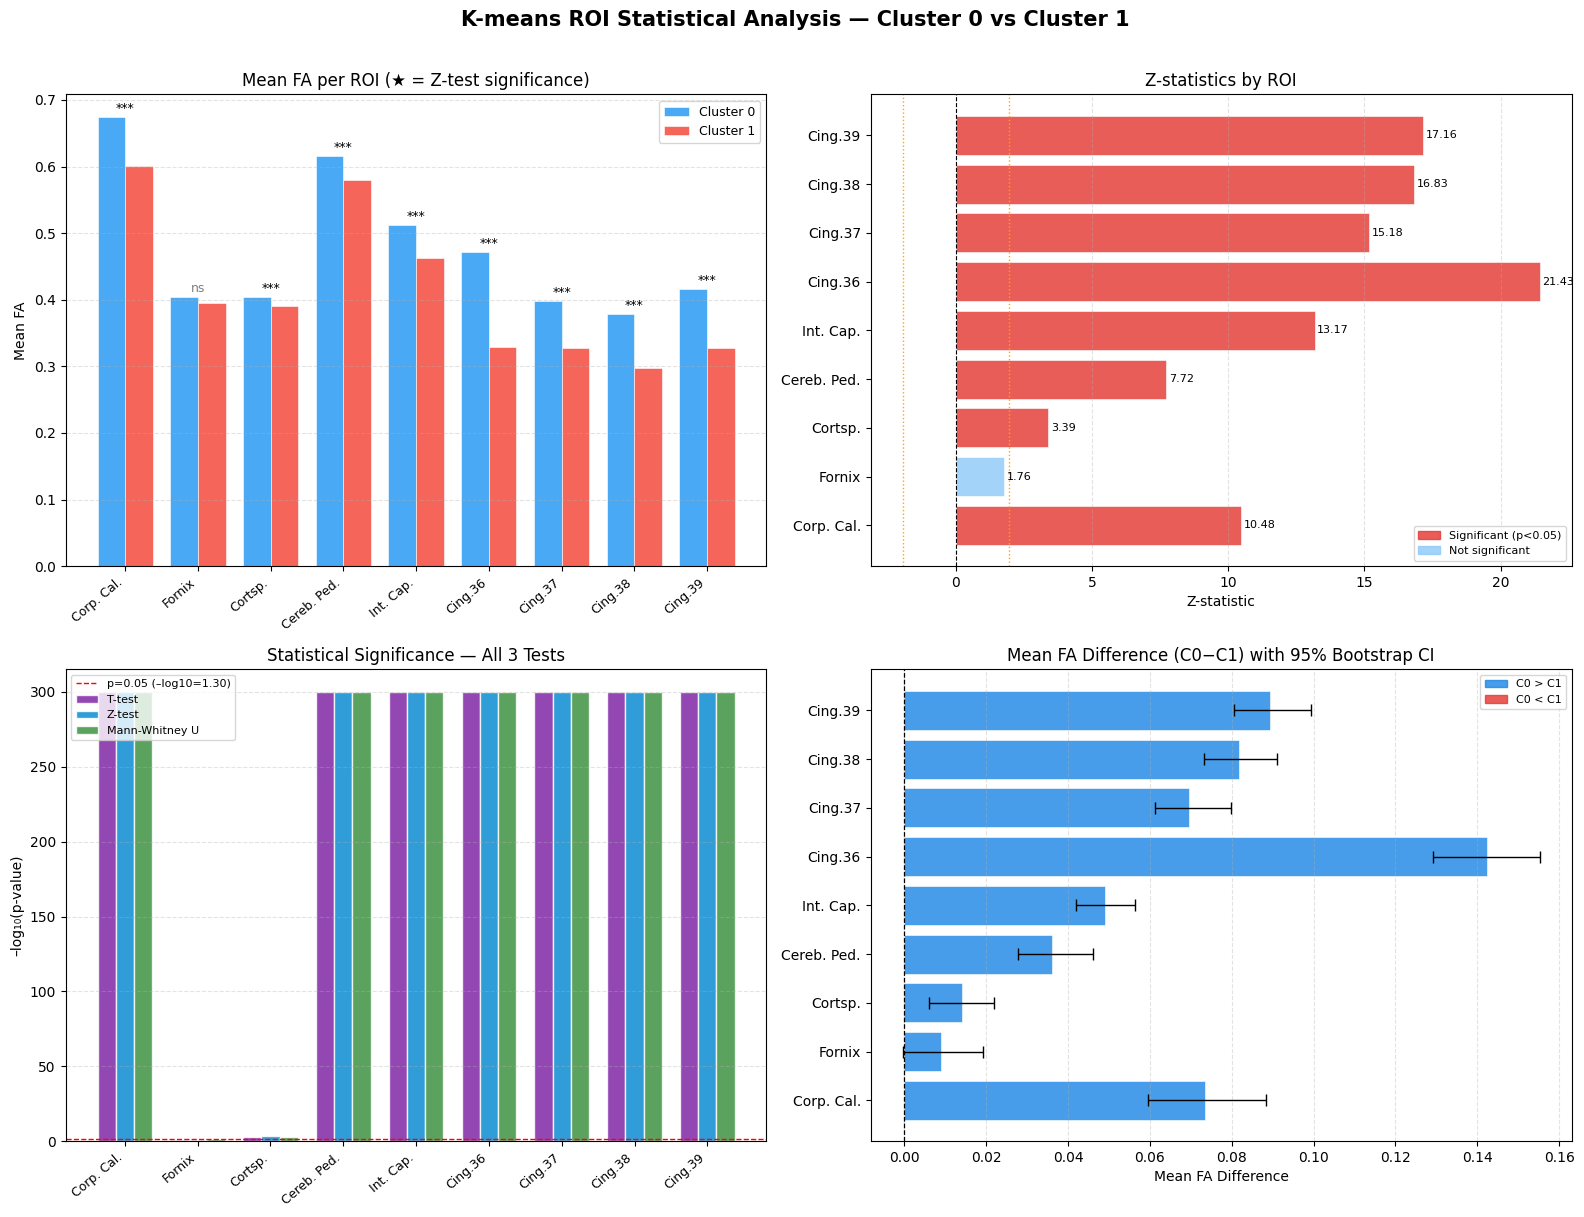

Saved: kmeans_roi_combined_stats.png


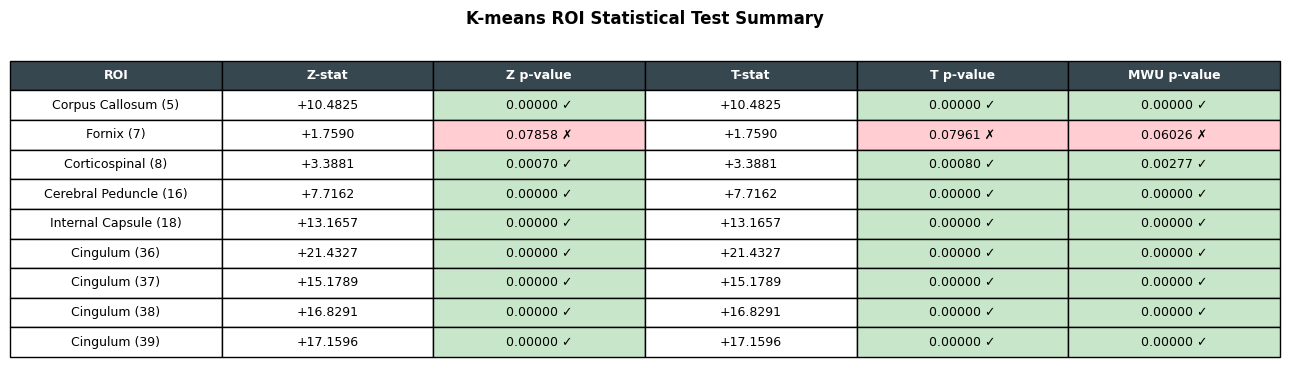

Saved: kmeans_roi_pvalue_table.png


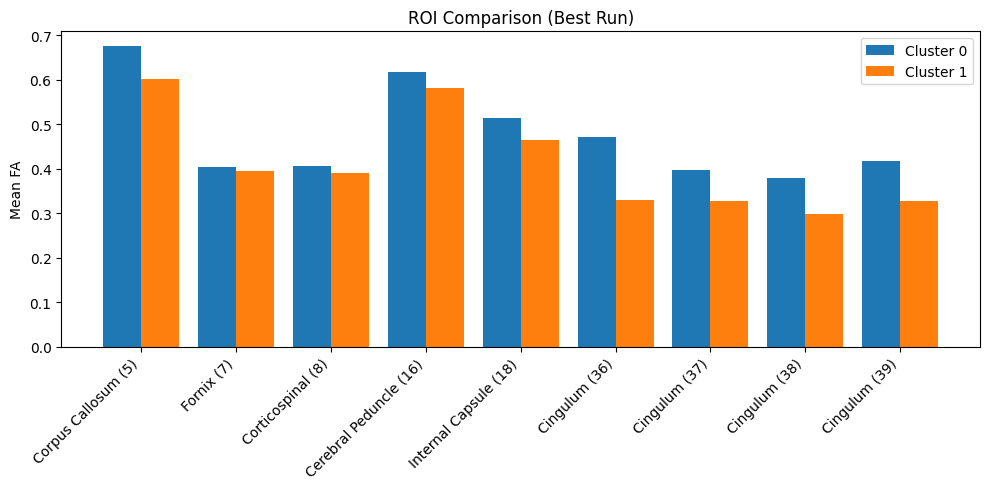

Saved: kmeans_roi_barplot.png


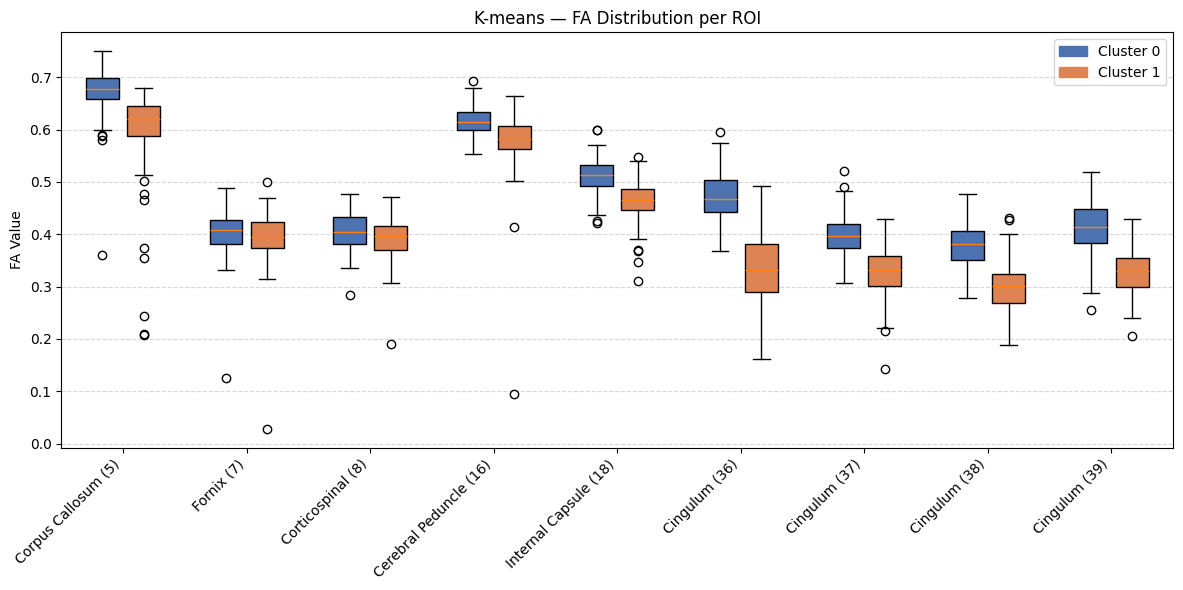

Saved: kmeans_roi_boxplot.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, normalized_mutual_info_score
)
from torch.nn import CrossEntropyLoss
from collections import Counter
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.weightstats import ztest
import torch

# ════════════════════════════════════════════════════════════════════
#  LOAD DATA
# ════════════════════════════════════════════════════════════════════
fa_feature_path = "/home/snu/Downloads/Histogram_CN_FA_20bin_updated.npy"
CN = np.load(fa_feature_path, allow_pickle=True)

fa_feature_path = "/home/snu/Downloads/Histogram_MCI_FA_20bin_updated.npy"
MCI = np.load(fa_feature_path, allow_pickle=True)

X = np.vstack([CN, MCI])
y = np.hstack([
    np.zeros(CN.shape[0], dtype=np.int64),
    np.ones(MCI.shape[0],  dtype=np.int64)
])

np.random.seed(42)
perm = np.random.permutation(X.shape[0])
X    = X[perm]
y    = y[perm]
F    = X.astype(np.float32)

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = CrossEntropyLoss()

# ════════════════════════════════════════════════════════════════════
#  ROI CONFIG
# ════════════════════════════════════════════════════════════════════
num_rois     = 9
bins_per_roi = 20

roi_names = [
    "Corpus Callosum (5)", "Fornix (7)", "Corticospinal (8)",
    "Cerebral Peduncle (16)", "Internal Capsule (18)",
    "Cingulum (36)", "Cingulum (37)", "Cingulum (38)", "Cingulum (39)"
]
short_names = [
    "Corp. Cal.", "Fornix", "Cortsp.",
    "Cereb. Ped.", "Int. Cap.",
    "Cing.36", "Cing.37", "Cing.38", "Cing.39"
]

roi_indices = {
    roi_names[i]: (i * bins_per_roi, (i + 1) * bins_per_roi)
    for i in range(num_rois)
}

bin_edges   = np.linspace(0, 1, bins_per_roi + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ════════════════════════════════════════════════════════════════════
#  RUN KMEANS (10 runs)
# ════════════════════════════════════════════════════════════════════
num_runs = 10
results  = []

for run in range(num_runs):
    print(f"\n--- Run {run+1}/{num_runs} ---")

    kmeans = KMeans(n_clusters=2, random_state=run, max_iter=5000)
    kmeans.fit(F)

    probs = kmeans.transform(F)
    probs = probs / probs.sum(axis=1, keepdims=True)

    y_pred  = np.argmax(probs, axis=1)
    acc     = accuracy_score(y, y_pred)
    acc_inv = accuracy_score(y, 1 - y_pred)

    if acc_inv > acc:
        y_pred          = 1 - y_pred
        probs[:, [0,1]] = probs[:, [1,0]]
        acc             = acc_inv

    prec = precision_score(y, y_pred, zero_division=0)
    rec  = recall_score(y, y_pred,    zero_division=0)
    f1   = f1_score(y, y_pred,        zero_division=0)
    ll   = log_loss(y, probs[:, 1])
    nmi  = normalized_mutual_info_score(y, y_pred, average_method='arithmetic')

    print(f"Acc={acc:.4f}, F1={f1:.4f}, NMI={nmi:.4f}")

    results.append({
        "run": run, "acc": acc, "prec": prec,
        "rec": rec, "f1": f1, "ll": ll, "nmi": nmi,
        "y_pred": y_pred, "probs": probs
    })

# ════════════════════════════════════════════════════════════════════
#  SUMMARY
# ════════════════════════════════════════════════════════════════════
accs  = [r["acc"]  for r in results]
precs = [r["prec"] for r in results]
recs  = [r["rec"]  for r in results]
f1s   = [r["f1"]   for r in results]
lls   = [r["ll"]   for r in results]
nmis  = [r["nmi"]  for r in results]

print("\n--- RESULTS (mean ± std over runs) ---")
print(f"Accuracy:  {np.mean(accs):.4f}  ± {np.std(accs):.4f}")
print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
print(f"Recall:    {np.mean(recs):.4f}  ± {np.std(recs):.4f}")
print(f"F1 Score:  {np.mean(f1s):.4f}  ± {np.std(f1s):.4f}")
print(f"NMI:       {np.mean(nmis):.4f}  ± {np.std(nmis):.4f}")
print(f"Log Loss:  {np.mean(lls):.4f}  ± {np.std(lls):.4f}")

# ════════════════════════════════════════════════════════════════════
#  BEST RUN
# ════════════════════════════════════════════════════════════════════
best   = max(results, key=lambda x: x["acc"])
y_pred = best["y_pred"]

print(f"\nBEST RUN: {best['run']}  "
      f"Acc={best['acc']:.4f}  F1={best['f1']:.4f}  NMI={best['nmi']:.4f}")

# ════════════════════════════════════════════════════════════════════
#  SAVE LABELS & DATA
# ════════════════════════════════════════════════════════════════════
np.save("/home/snu/Downloads/kmeans_labels.npy", y_pred)
np.save("/home/snu/Downloads/X.npy", X)
np.save("/home/snu/Downloads/y.npy", y)
print("\nSaved: kmeans_labels.npy | X.npy | y.npy")

# ════════════════════════════════════════════════════════════════════
#  COMPUTE ALL STATS  (T-test, Z-test, Mann-Whitney U)
# ════════════════════════════════════════════════════════════════════
print("\n===== COMMUNITY LEVEL ANALYSIS =====\n")
for k in range(2):
    print(f"Cluster {k}:", Counter(y[y_pred == k]))

roi_stats = {}
for roi, (start, end) in roi_indices.items():
    vals = []
    for k in range(2):
        roi_hist = X[y_pred == k, start:end]
        weighted = (roi_hist * bin_centers).sum(axis=1)
        vals.append(weighted.mean())
    roi_stats[roi] = vals

records = []
for roi, (start, end) in roi_indices.items():
    c0_vals = (X[y_pred == 0, start:end] * bin_centers).sum(axis=1)
    c1_vals = (X[y_pred == 1, start:end] * bin_centers).sum(axis=1)

    mean_c0 = c0_vals.mean()
    mean_c1 = c1_vals.mean()
    diff    = mean_c0 - mean_c1

    t_stat, t_pval = ttest_ind(c0_vals, c1_vals)
    z_stat, z_pval = ztest(c0_vals, c1_vals, value=0)
    u_stat, u_pval = mannwhitneyu(c0_vals, c1_vals, alternative='two-sided')

    records.append({
        "ROI":     roi,
        "Mean_C0": round(mean_c0, 4),
        "Mean_C1": round(mean_c1, 4),
        "Diff":    round(diff, 4),
        "T_stat":  round(t_stat, 4),
        "T_pval":  round(t_pval, 6),
        "T_sig":   t_pval < 0.05,
        "Z_stat":  round(z_stat, 4),
        "Z_pval":  round(z_pval, 6),
        "Z_sig":   z_pval < 0.05,
        "U_stat":  round(u_stat, 4),
        "U_pval":  round(u_pval, 6),
        "U_sig":   u_pval < 0.05,
    })

df = pd.DataFrame(records)

# ── Save CSV ──────────────────────────────────────────────────────
df.to_csv("/home/snu/Downloads/kmeans_roi_stats.csv", index=False)
print("\nSaved: kmeans_roi_stats.csv")
print(df.to_string(index=False))

# ── Print tables ──────────────────────────────────────────────────
print("\nStatistical Significance (T-test):\n")
print(f"{'ROI':<30} | {'T-stat':>10} | {'P-value':>10} | {'Significant':>12}")
print("-" * 70)
for _, row in df.iterrows():
    sig = "Yes ✓" if row["T_sig"] else "No"
    print(f"{row['ROI']:<30} | {row['T_stat']:>10.4f} | {row['T_pval']:>10.5f} | {sig:>12}")

print("\nStatistical Significance (2-Sample Z-test):\n")
print(f"{'ROI':<30} | {'Z-stat':>10} | {'P-value':>10} | {'Significant':>12}")
print("-" * 70)
for _, row in df.iterrows():
    sig = "Yes ✓" if row["Z_sig"] else "No"
    print(f"{row['ROI']:<30} | {row['Z_stat']:>10.4f} | {row['Z_pval']:>10.5f} | {sig:>12}")

# ════════════════════════════════════════════════════════════════════
#  COMBINED 4-PANEL FIGURE
# ════════════════════════════════════════════════════════════════════
x     = np.arange(len(roi_names))
width = 0.38
alpha = 0.82

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "K-means ROI Statistical Analysis — Cluster 0 vs Cluster 1",
    fontsize=15, fontweight='bold', y=1.01
)

# ── Panel 1 : Mean FA bar chart ───────────────────────────────────
ax = axes[0, 0]
ax.bar(x - width/2, df["Mean_C0"], width, label="Cluster 0",
       color="#2196F3", alpha=alpha, edgecolor='white', linewidth=0.5)
ax.bar(x + width/2, df["Mean_C1"], width, label="Cluster 1",
       color="#F44336", alpha=alpha, edgecolor='white', linewidth=0.5)

for i, row in df.iterrows():
    stars = ("***" if row["Z_pval"] < 0.001 else
             "**"  if row["Z_pval"] < 0.01  else
             "*"   if row["Z_pval"] < 0.05  else "ns")
    ymax  = max(row["Mean_C0"], row["Mean_C1"]) + 0.003
    ax.text(i, ymax, stars, ha='center', va='bottom', fontsize=9,
            color='black' if stars != "ns" else 'gray')

ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=9)
ax.set_ylabel("Mean FA")
ax.set_title("Mean FA per ROI (★ = Z-test significance)")
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.35)

# ── Panel 2 : Z-statistics ────────────────────────────────────────
ax = axes[0, 1]
colors_z = ["#E53935" if s else "#90CAF9" for s in df["Z_sig"]]
bars     = ax.barh(short_names, df["Z_stat"], color=colors_z,
                   edgecolor='white', linewidth=0.5, alpha=alpha)
ax.axvline(0,     color='black',  linewidth=0.8, linestyle='--')
ax.axvline(-1.96, color='orange', linewidth=1,   linestyle=':', label='±1.96 threshold')
ax.axvline( 1.96, color='orange', linewidth=1,   linestyle=':')

for bar, val in zip(bars, df["Z_stat"]):
    ax.text(val - 0.3 if val < 0 else val + 0.1,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va='center',
            ha='right' if val < 0 else 'left', fontsize=8)

sig_patch   = mpatches.Patch(color='#E53935', alpha=alpha, label='Significant (p<0.05)')
unsig_patch = mpatches.Patch(color='#90CAF9', alpha=alpha, label='Not significant')
ax.legend(handles=[sig_patch, unsig_patch], fontsize=8, loc='lower right')
ax.set_title("Z-statistics by ROI")
ax.set_xlabel("Z-statistic")
ax.grid(axis='x', linestyle='--', alpha=0.35)

# ── Panel 3 : –log10(p-value) all 3 tests ────────────────────────
ax    = axes[1, 0]
log_t = -np.log10(df["T_pval"].clip(lower=1e-300))
log_z = -np.log10(df["Z_pval"].clip(lower=1e-300))
log_u = -np.log10(df["U_pval"].clip(lower=1e-300))
w3    = 0.25

ax.bar(x - w3, log_t, w3, label="T-test",        color="#7B1FA2", alpha=alpha, edgecolor='white')
ax.bar(x,      log_z, w3, label="Z-test",         color="#0288D1", alpha=alpha, edgecolor='white')
ax.bar(x + w3, log_u, w3, label="Mann-Whitney U", color="#388E3C", alpha=alpha, edgecolor='white')

threshold_line = -np.log10(0.05)
ax.axhline(threshold_line, color='red', linestyle='--', linewidth=1,
           label=f'p=0.05 (–log10={threshold_line:.2f})')

ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=9)
ax.set_ylabel("–log₁₀(p-value)")
ax.set_title("Statistical Significance — All 3 Tests")
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.35)

# ── Panel 4 : Signed mean diff + bootstrap CI ─────────────────────
ax = axes[1, 1]
np.random.seed(42)
ci_low, ci_high = [], []
for roi, (start, end) in roi_indices.items():
    c0v = (X[y_pred == 0, start:end] * bin_centers).sum(axis=1)
    c1v = (X[y_pred == 1, start:end] * bin_centers).sum(axis=1)
    boot_diffs = [
        np.random.choice(c0v, len(c0v), replace=True).mean() -
        np.random.choice(c1v, len(c1v), replace=True).mean()
        for _ in range(1000)
    ]
    ci_low.append(np.percentile(boot_diffs, 2.5))
    ci_high.append(np.percentile(boot_diffs, 97.5))

diffs    = df["Diff"].values
err_low  = diffs - np.array(ci_low)
err_high = np.array(ci_high) - diffs
colors_d = ["#E53935" if d < 0 else "#1E88E5" for d in diffs]

ax.barh(short_names, diffs,
        xerr=[err_low, err_high],
        color=colors_d, alpha=alpha,
        edgecolor='white', linewidth=0.5,
        error_kw=dict(ecolor='black', capsize=4, linewidth=1))
ax.axvline(0, color='black', linewidth=0.9, linestyle='--')
ax.set_title("Mean FA Difference (C0−C1) with 95% Bootstrap CI")
ax.set_xlabel("Mean FA Difference")
ax.grid(axis='x', linestyle='--', alpha=0.35)

pos_patch = mpatches.Patch(color='#1E88E5', alpha=alpha, label='C0 > C1')
neg_patch = mpatches.Patch(color='#E53935', alpha=alpha, label='C0 < C1')
ax.legend(handles=[pos_patch, neg_patch], fontsize=8)

plt.tight_layout()
plt.savefig("/home/snu/Downloads/kmeans_roi_combined_stats.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: kmeans_roi_combined_stats.png")

# ════════════════════════════════════════════════════════════════════
#  P-VALUE SUMMARY TABLE AS IMAGE
# ════════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(13, 4))
ax2.axis('off')

table_data = []
for _, row in df.iterrows():
    def fmt(pval, sig):
        return f"{pval:.5f} {'✓' if sig else '✗'}"
    table_data.append([
        row["ROI"],
        f"{row['Z_stat']:+.4f}",
        fmt(row["Z_pval"], row["Z_sig"]),
        f"{row['T_stat']:+.4f}",
        fmt(row["T_pval"], row["T_sig"]),
        fmt(row["U_pval"], row["U_sig"]),
    ])

col_labels = ["ROI", "Z-stat", "Z p-value", "T-stat", "T p-value", "MWU p-value"]
tbl = ax2.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

for (row_idx, col_idx), cell in tbl.get_celld().items():
    if row_idx == 0:
        cell.set_facecolor('#37474F')
        cell.set_text_props(color='white', fontweight='bold')
    elif col_idx in [2, 4, 5]:
        txt = cell.get_text().get_text()
        cell.set_facecolor('#C8E6C9' if '✓' in txt else '#FFCDD2')

ax2.set_title("K-means ROI Statistical Test Summary",
              fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig("/home/snu/Downloads/kmeans_roi_pvalue_table.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: kmeans_roi_pvalue_table.png")

# ════════════════════════════════════════════════════════════════════
#  ORIGINAL BAR + BOX PLOTS
# ════════════════════════════════════════════════════════════════════
roi_means_c0 = [roi_stats[r][0] for r in roi_names]
roi_means_c1 = [roi_stats[r][1] for r in roi_names]
x_pos        = np.arange(len(roi_names))

plt.figure(figsize=(10, 5))
plt.bar(x_pos - 0.2, roi_means_c0, width=0.4, label="Cluster 0")
plt.bar(x_pos + 0.2, roi_means_c1, width=0.4, label="Cluster 1")
plt.xticks(x_pos, roi_names, rotation=45, ha='right')
plt.ylabel("Mean FA")
plt.title("ROI Comparison (Best Run)")
plt.legend()
plt.tight_layout()
plt.savefig("/home/snu/Downloads/kmeans_roi_barplot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: kmeans_roi_barplot.png")

color_c0 = "#4C72B0"
color_c1 = "#DD8452"

plt.figure(figsize=(12, 6))
positions, data, colors = [], [], []
gap, bw = 1.5, 0.5

for i, (roi, (start, end)) in enumerate(roi_indices.items()):
    c0 = (X[y_pred == 0, start:end] * bin_centers).sum(axis=1)
    c1 = (X[y_pred == 1, start:end] * bin_centers).sum(axis=1)
    positions += [i * gap, i * gap + bw]
    data      += [c0, c1]
    colors    += [color_c0, color_c1]

box = plt.boxplot(data, positions=positions, widths=0.4, patch_artist=True)
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

xticks = [i * gap + bw / 2 for i in range(len(roi_names))]
plt.xticks(xticks, roi_names, rotation=45, ha='right')
plt.ylabel("FA Value")
plt.title("K-means — FA Distribution per ROI")
plt.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color=color_c0),
        plt.Rectangle((0, 0), 1, 1, color=color_c1)
    ],
    labels=["Cluster 0", "Cluster 1"]
)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("/home/snu/Downloads/kmeans_roi_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: kmeans_roi_boxplot.png")

In [ ]:
print(f"{roi:<30} | {abs(z_stat):>10.4f} | {p:>10.5f} | {significant:>12}")

Cingulum (39)                  |    17.1596 |    0.00000 |        Yes ✓


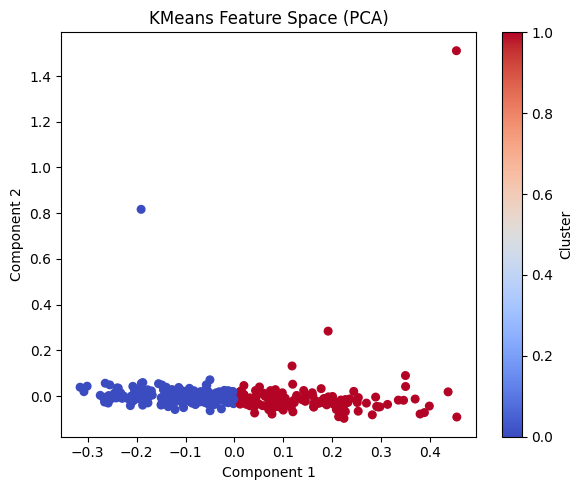

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# -------- PCA on INPUT FEATURES --------
pca = PCA(n_components=2)
Z = pca.fit_transform(X)

# -------- PLOT --------
plt.figure(figsize=(6,5))
plt.scatter(Z[:,0], Z[:,1], c=y_pred, cmap='coolwarm', s=30)

plt.title("KMeans Feature Space (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster")

plt.tight_layout()
plt.show()


--- Run 1/10 (PCA-KMeans) ---
Run 1 | Acc: 0.7200 | Prec: 0.7943 | Rec: 0.6707 | F1: 0.7273 | NMI: 0.1540 | LogLoss: 0.6273

--- Run 2/10 (PCA-KMeans) ---
Run 2 | Acc: 0.7200 | Prec: 0.7943 | Rec: 0.6707 | F1: 0.7273 | NMI: 0.1540 | LogLoss: 0.6273

--- Run 3/10 (PCA-KMeans) ---
Run 3 | Acc: 0.7067 | Prec: 0.8062 | Rec: 0.6228 | F1: 0.7027 | NMI: 0.1462 | LogLoss: 0.6371

--- Run 4/10 (PCA-KMeans) ---
Run 4 | Acc: 0.7200 | Prec: 0.7943 | Rec: 0.6707 | F1: 0.7273 | NMI: 0.1540 | LogLoss: 0.6280

--- Run 5/10 (PCA-KMeans) ---
Run 5 | Acc: 0.7067 | Prec: 0.8062 | Rec: 0.6228 | F1: 0.7027 | NMI: 0.1462 | LogLoss: 0.6371

--- Run 6/10 (PCA-KMeans) ---
Run 6 | Acc: 0.7200 | Prec: 0.7943 | Rec: 0.6707 | F1: 0.7273 | NMI: 0.1540 | LogLoss: 0.6273

--- Run 7/10 (PCA-KMeans) ---
Run 7 | Acc: 0.7033 | Prec: 0.7955 | Rec: 0.6287 | F1: 0.7023 | NMI: 0.1385 | LogLoss: 0.6345

--- Run 8/10 (PCA-KMeans) ---
Run 8 | Acc: 0.7200 | Prec: 0.7943 | Rec: 0.6707 | F1: 0.7273 | NMI: 0.1540 | LogLoss: 0.6280


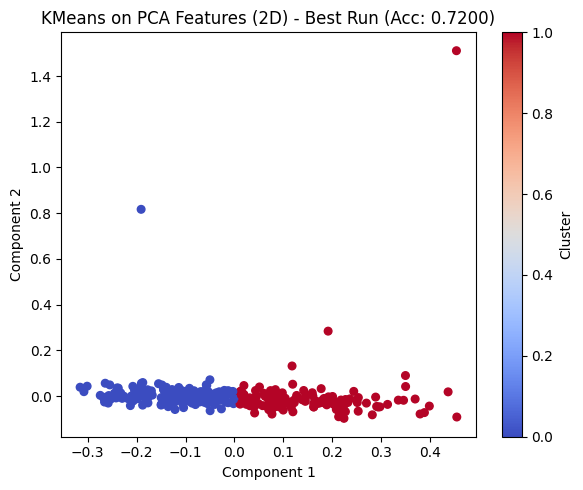

In [4]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, normalized_mutual_info_score
import numpy as np

# -------- PCA on INPUT FEATURES --------
pca = PCA(n_components=2)
Z   = pca.fit_transform(X)   # Z is now (N, 2)

num_runs = 10
results_pca = []

for run in range(num_runs):
    print(f"\n--- Run {run+1}/{num_runs} (PCA-KMeans) ---")
    np.random.seed(run) # Ensure reproducibility for KMeans within the loop

    # -------- KMEANS ON 2D PCA FEATURES --------
    kmeans_pca = KMeans(n_clusters=2, random_state=run, max_iter=5000, n_init='auto')
    kmeans_pca.fit(Z)

    probs_pca = kmeans_pca.transform(Z)
    probs_pca = probs_pca / probs_pca.sum(axis=1, keepdims=True)

    y_pred_pca = np.argmax(probs_pca, axis=1)

    # Fix label flip
    acc     = accuracy_score(y, y_pred_pca)
    acc_inv = accuracy_score(y, 1 - y_pred_pca)
    if acc_inv > acc:
        y_pred_pca          = 1 - y_pred_pca
        probs_pca[:, [0,1]] = probs_pca[:, [1,0]]
        acc                 = acc_inv

    prec = precision_score(y, y_pred_pca, zero_division=0)
    rec  = recall_score(y, y_pred_pca,    zero_division=0)
    f1   = f1_score(y, y_pred_pca,        zero_division=0)
    ll   = log_loss(y, probs_pca[:, 1])
    nmi  = normalized_mutual_info_score(y, y_pred_pca, average_method='arithmetic')

    print(f"Run {run+1} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | "
          f"F1: {f1:.4f} | NMI: {nmi:.4f} | LogLoss: {ll:.4f}")

    results_pca.append({
        "run": run, "acc": acc, "prec": prec,
        "rec": rec, "f1": f1, "ll": ll, "nmi": nmi,
        "y_pred": y_pred_pca, "probs": probs_pca
    })

# ════════════════════════════════════════════════════════════════════
#  SUMMARY FOR PCA-KMEANS
# ════════════════════════════════════════════════════════════════════
accs_pca  = [r["acc"]  for r in results_pca]
precs_pca = [r["prec"] for r in results_pca]
recs_pca  = [r["rec"]  for r in results_pca]
f1s_pca   = [r["f1"]   for r in results_pca]
lls_pca   = [r["ll"]   for r in results_pca]
nmis_pca  = [r["nmi"]  for r in results_pca]

print("\n================ FINAL SUMMARY (PCA-KMeans) ================\n")
print(f"{'Metric':>15} | {'Mean':>10} \u00B1 {'Std':<10}")
print("-" * 50)
print(f"{'Accuracy':>15} | {np.mean(accs_pca):.4f} \u00B1 {np.std(accs_pca):.4f}")
print(f"{'Precision':>15} | {np.mean(precs_pca):.4f} \u00B1 {np.std(precs_pca):.4f}")
print(f"{'Recall':>15} | {np.mean(recs_pca):.4f} \u00B1 {np.std(recs_pca):.4f}")
print(f"{'F1 Score':>15} | {np.mean(f1s_pca):.4f} \u00B1 {np.std(f1s_pca):.4f}")
print(f"{'NMI':>15} | {np.mean(nmis_pca):.4f} \u00B1 {np.std(nmis_pca):.4f}")
print(f"{'Log Loss':>15} | {np.mean(lls_pca):.4f} \u00B1 {np.std(lls_pca):.4f}")

# Get the best run for plotting
best_pca = max(results_pca, key=lambda x: x["acc"])
y_pred_pca_best = best_pca["y_pred"]

# -------- PLOT for the best run --------
plt.figure(figsize=(6, 5))
plt.scatter(Z[:, 0], Z[:, 1], c=y_pred_pca_best, cmap='coolwarm', s=30)
plt.title(f"KMeans on PCA Features (2D) - Best Run (Acc: {best_pca['acc']:.4f})")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()

### t-SNE Visualization of K-Means Clustering

This section uses t-Distributed Stochastic Neighbor Embedding (t-SNE) to reduce the high-dimensional feature space (`X`) to two dimensions. The resulting 2D points are then plotted, with colors indicating the cluster assignments (`y_pred`) obtained from the k-means algorithm. This visualization helps to understand the separability and distribution of the clusters in a lower-dimensional space.

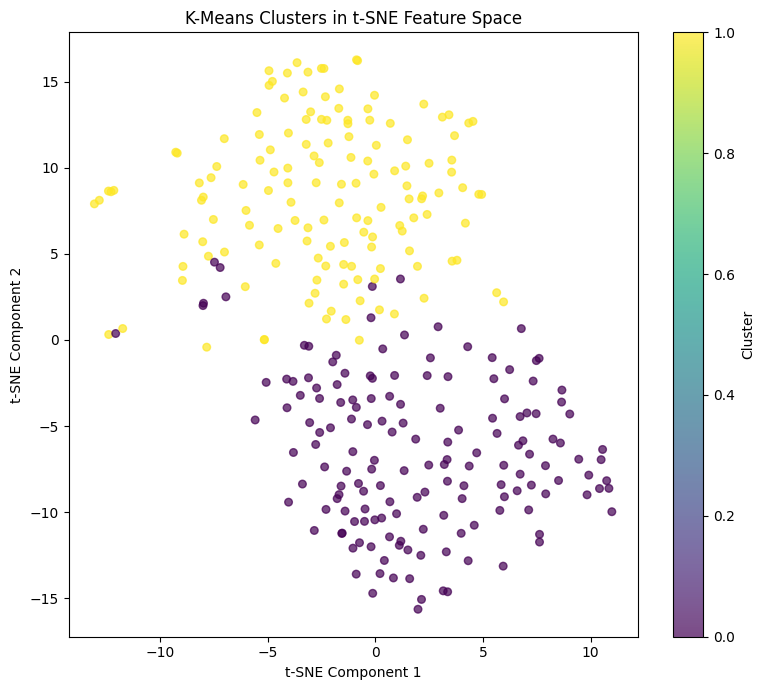

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# -------- t-SNE on INPUT FEATURES --------
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
# You might need to adjust 'perplexity' based on your dataset size and characteristics.
# Larger datasets might benefit from higher perplexity, but keep it less than (n_samples - 1).
# If your dataset is very small, a lower perplexity (e.g., 5 or 10) might be necessary.
# Here, the default (30) is used as a starting point.
Z_tsne = tsne.fit_transform(X)

# -------- PLOT --------
plt.figure(figsize=(8, 7))
scatter = plt.scatter(Z_tsne[:, 0], Z_tsne[:, 1], c=y_pred, cmap='viridis', s=30, alpha=0.7)

plt.title("K-Means Clusters in t-SNE Feature Space")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.colorbar(scatter, label="Cluster")

plt.tight_layout()
plt.show()